In [1]:
import requests
import json
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

# 1. Fetch the data
url = "https://tcp-us-prod-rnd.shl.com/voiceRater/shl-ai-hiring/shl_product_catalog.json"
response = requests.get(url)

#  Use json.loads with strict=False to handle invalid control characters
try:
    catalog_data = json.loads(response.text, strict=False)
except Exception as e:
    print(f"Error decoding JSON: {e}")
    catalog_data = []

# 2. Function to determine Test Type (K for Knowledge, P for Personality)
def get_test_type(keys):
    if not keys: return "Other"
    keys_str = " ".join(keys).lower()
    if any(k in keys_str for k in ["knowledge", "skills"]):
        return "K"
    if any(k in keys_str for k in ["personality", "behavior"]):
        return "P"
    if any(k in keys_str for k in ["ability", "aptitude"]):
        return "A"
    if any(k in keys_str for k in ["biodata", "situational judgement"]):
        return "B"
    if any(k in keys_str for k in ["competencies"]):
        return "C"
    if any(k in keys_str for k in ["development", "360"]):
        return "D"
    if any(k in keys_str for k in ["Assessment", "Exercises"]):
        return "E"
    if any(k in keys_str for k in ["Simulations"]):
        return "S"
    

# 3. Transform into LangChain Documents with your specific fields
documents = []

for item in catalog_data:
    # Metadata extraction
    name = item.get("name", "N/A")
    keys = item.get("keys", [])
    test_type = get_test_type(keys)
    duration = item.get("duration", "N/A")
    languages = ", ".join(item.get("languages", []))
    url_link = item.get("link", "N/A")
    description = item.get("description", "")

    # We embed the name and description for semantic search
    page_content = f"Test Name: {name}. Description: {description}"

    # Metadata stores only the fields you requested
    metadata = {
        "Name": name,
        "Test Type": test_type,
        "Keys": ", ".join(keys),
        "Duration": duration,
        "Languages": languages,
        "URL": url_link
    }

    documents.append(Document(page_content=page_content, metadata=metadata))

# 4. Initialize Embeddings and Vector DB
if documents:
    embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
    vector_db = FAISS.from_documents(documents, embeddings)
    
    # 5. Save the index locally
    vector_db.save_local("shl_faiss_index")
    print(f"Successfully stored {len(documents)} documents in FAISS index.")
else:
    print("No documents found to index.")

e:\Agentic AI\Project\5-\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7541.47it/s]


Successfully stored 377 documents in FAISS index.


In [2]:
from typing import Annotated, List, TypedDict, Dict
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    # The full conversation history
    messages: Annotated[list, add_messages]
    # Extracted requirements (seniority, role, skills)
    context_extracted: Dict[str, str]
    # Data retrieved from FAISS
    retrieved_docs: List[dict]
    # The final formatted response
    reply: str
    # Evaluation flags
    is_ready: bool
    end_of_conversation: bool

In [11]:
SYSTEM_PROMPT = """
You are the SHL Assessment Recommender. Your goal is to guide recruiters to the right products.

CORE BEHAVIORS:
1. CLARIFICATION: If the query is vague (e.g., "I need a test"), you MUST ask for:
   - Seniority (Graduate, Mid-Pro, Executive)
   - Role/Skills (Java, Leadership, etc.)
2. RECOMMENDATION: Once context is clear, provide 1-10 assessments from the catalog ONLY.
3. COMPARISON: Use descriptions to explain differences between specific tests.
4. SCOPE: Refuse non-SHL topics (legal, general hiring).

RESPONSE FORMAT:
- A brief professional summary.
- A Markdown table: | # | Name | Test Type | Keys | Duration | Languages | URL |
- URLs MUST be in <brackets>.
- Test Type: 'K' for Knowledge/Ability, 'P' for Personality/Behavior.

Grounded only on the provided context. If no context matches, state you couldn't find a specific SHL product.
"""

In [12]:
from google import genai
from google.genai import types
import os
client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

def intent_router_node(state: AgentState):
    user_input = state["messages"][-1].content
    
    # Prompt Gemini to check if we have enough info for a search
    check_prompt = f"Does the following request provide enough detail (role/seniority) to search a catalog? Request: {user_input}. Reply ONLY with 'READY' or 'CLARIFY'."
    
    response = client.models.generate_content(
        model="gemini-3.1-flash-lite",
        contents=check_prompt
    )
    
    return {"is_ready": "READY" in response.text.upper()}

In [13]:
def retriever_node(state: AgentState):
    query = state["messages"][-1].content
    # Use the FAISS index loaded in memory
    docs = vector_db.similarity_search(query, k=10)
    
    # Extract metadata for the response array
    recommendations = [d.metadata for d in docs]
    return {"retrieved_docs": recommendations}

In [14]:
def generator_node(state: AgentState):
    docs_context = "\n".join([str(d) for d in state["retrieved_docs"]])
    history = "\n".join([f"{m.type}: {m.content}" for m in state["messages"]])
    
    full_content = f"{SYSTEM_PROMPT}\n\nCATALOG CONTEXT:\n{docs_context}\n\nHISTORY:\n{history}"
    
    response = client.models.generate_content(
        model="gemini-3.1-flash-lite",
        contents=full_content
    )
    
    return {
        "reply": response.text,
        "end_of_conversation": "|" in response.text # Usually ends after a table
    }

In [15]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(AgentState)

# Define Nodes
workflow.add_node("intent_router", intent_router_node)
workflow.add_node("retriever", retriever_node)
workflow.add_node("generator", generator_node)

# Define Logic
workflow.set_entry_point("intent_router")

workflow.add_conditional_edges(
    "intent_router",
    lambda x: "retriever" if x["is_ready"] else "generator",
    {"retriever": "retriever", "generator": "generator"}
)

workflow.add_edge("retriever", "generator")
workflow.add_edge("generator", END)

app_graph = workflow.compile()

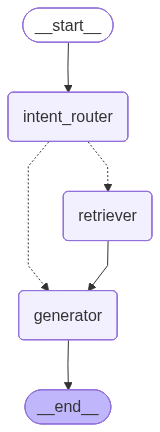

In [16]:
from IPython.display import Image, display
display(Image(app_graph.get_graph().draw_mermaid_png()))

In [17]:
from langchain_core.messages import HumanMessage
# 1. Prepare the initial state
initial_state = {
    "messages": [HumanMessage(content="I am hiring a senior level python developer")],
    "is_ready": False,
    "retrieved_docs": []
}

# 2. Run the graph to completion
final_state = app_graph.invoke(initial_state)

# 3. Extract your specific "answer" keys
# These are the keys you defined in your TypedDict State
answer_text = final_state.get("reply")
shortlist = final_state.get("retrieved_docs")
is_finished = final_state.get("end_of_conversation")

print(f"Agent Reply: {answer_text}")

Agent Reply: To assist you in selecting the most effective assessment for a senior-level Python developer, I have identified solutions that evaluate both technical coding proficiency and the soft skills necessary for a senior role.

For a senior developer, I recommend combining the **Python (New)** test to verify core technical competency with **Smart Interview Live Coding** to observe problem-solving processes in real-time. Additionally, if the role involves leading projects or working within a distributed team, the **RemoteWorkQ** suite provides valuable insights into behavioral readiness.

| # | Name | Test Type | Keys | Duration | Languages | URL |
|:---|:---|:---|:---|:---|:---|:---|
| 1 | Python (New) | K | Knowledge & Skills | 11 minutes | English (USA) | <https://www.shl.com/products/product-catalog/view/python-new/> |
| 2 | Smart Interview Live Coding | K | Knowledge & Skills | Variable | English (USA) | <https://www.shl.com/products/product-catalog/view/smart-interview-live-c